Install package

In [3]:
!pip install tensorflow-datasets

Import libraries

In [4]:
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

Load complete EMNIST Letters dataset

In [5]:
dataset = tfds.load(
    'emnist/letters',
    split='train',
    as_supervised=True
)

X=[]
y=[]

for image,label in tfds.as_numpy(dataset):
    X.append(image)
    y.append(label)

X=np.array(X)
y=np.array(y)

print("Image shape:",X.shape)
print("Label shape:",y.shape)
print("Classes:",np.unique(y))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.70YTRN_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.70YTRN_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
Image shape: (88800, 28, 28, 1)
Label shape: (88800,)
Classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26]


Fix EMNIST orientation

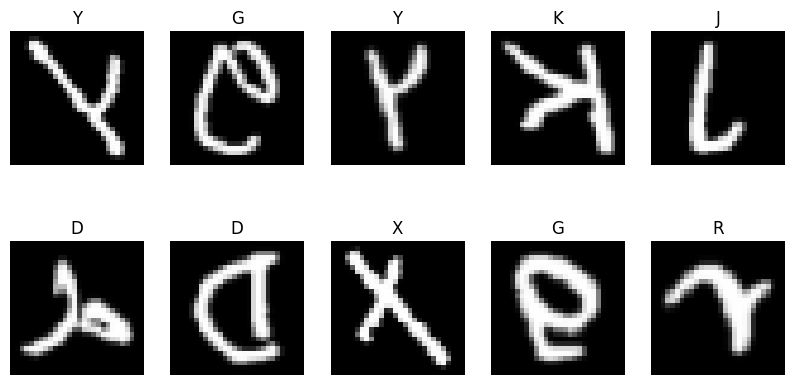

In [6]:
X = np.transpose(X,(0,2,1,3))
X = np.flip(X,axis=2)

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X[i],cmap='gray')
    plt.title(chr(y[i]+64))
    plt.axis("off")

plt.show()

Preprocessing

In [7]:
X = X.reshape(-1,784)
X = X/255.0

# Labels: 1–26 → 0–25
y = y-1

# Split data
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# One hot encoding
y_train=to_categorical(y_train,26)
y_test=to_categorical(y_test,26)

print(X_train.shape)
print(X_test.shape)

(71040, 784)
(17760, 784)


Create ANN model

In [8]:
model=Sequential()

model.add(Dense(
    512,
    activation='relu',
    input_shape=(784,)
))

model.add(Dropout(0.3))

model.add(Dense(
    256,
    activation='relu'
))

model.add(Dropout(0.3))

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.3))

model.add(Dense(
    26,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dense(64) → may learn fewer features
Dense(128) → moderate learning
Dense(256) → stronger feature learning
Dense(1024) → may become unnecessarily complex

=============

A **Dense layer** connects every neuron from the previous layer to every neuron in the next layer.
It helps the model learn patterns and relationships from the input data.
The number inside Dense() represents the number of neurons.

============

**Dropout is used to reduce overfitting in a neural network**

Simple explanation:

Imagine 100 students studying together. If the same students always answer every question, some students may become over-dependent on others.

Dropout works like this:

During training, it randomly turns off (drops) some neurons temporarily.
Example: Dropout(0.5) → randomly ignores 50% of neurons in each training step.
The network is forced to learn from different neuron combinations.
This prevents the model from memorizing the training data and helps it generalize better for new data.

================

**Dense(256) → creates 256 neurons**
--------------------------------------------------------

**Dropout(0.3) → randomly disables 30% of neurons during training**

Benefits:
✅ Reduces overfitting
✅ Improves generalization
✅ Makes predictions more reliable on unseen data
✅ Can improve accuracy

Compile model

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 569,498 (2.17 MB)

 Trainable params: 569,498 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

Train model

In [10]:
history=model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test,y_test)
)

Epoch 1/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6474 - loss: 1.1786 - val_accuracy: 0.8351 - val_loss: 0.5378
Epoch 2/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8044 - loss: 0.6314 - val_accuracy: 0.8695 - val_loss: 0.4167
Epoch 3/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8401 - loss: 0.5168 - val_accuracy: 0.8846 - val_loss: 0.3648
Epoch 4/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8565 - loss: 0.4554 - val_accuracy: 0.8890 - val_loss: 0.3444
Epoch 5/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8690 - loss: 0.4121 - val_accuracy: 0.8925 - val_loss: 0.3336
Epoch 6/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8765 - loss: 0.3829 - val_accuracy: 0.9001 - val_loss: 0.3132
Epoch 7/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8836 - loss: 0.3557 - val_accuracy: 0.8997 - val_loss: 0.3085
Epoch 8/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8884 - loss: 0.3418 - val_acc

Prediction

In [11]:
y_pred=model.predict(X_test)

y_pred_classes=np.argmax(
    y_pred,
    axis=1
)

y_true_classes=np.argmax(
    y_test,
    axis=1
)

555/555 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Classification Report

In [12]:
alphabet_labels=[
    chr(i)
    for i in range(65,91)
]

print(
    classification_report(
        y_true_classes,
        y_pred_classes,
        target_names=alphabet_labels
    )
)

              precision    recall  f1-score   support

           A       0.84      0.91      0.87       679
           B       0.92      0.94      0.93       679
           C       0.96      0.92      0.94       684
           D       0.94      0.89      0.92       680
           E       0.90      0.95      0.92       687
           F       0.95      0.92      0.94       679
           G       0.83      0.76      0.80       677
           H       0.93      0.92      0.92       685
           I       0.71      0.79      0.75       686
           J       0.92      0.91      0.91       680
           K       0.94      0.90      0.92       688
           L       0.75      0.71      0.73       683
           M       0.95      0.97      0.96       680
           N       0.92      0.92      0.92       673
           O       0.93      0.98      0.95       682
           P       0.95      0.96      0.95       686
           Q       0.82      0.80      0.81       687
           R       0.91    

Confusion Matrix

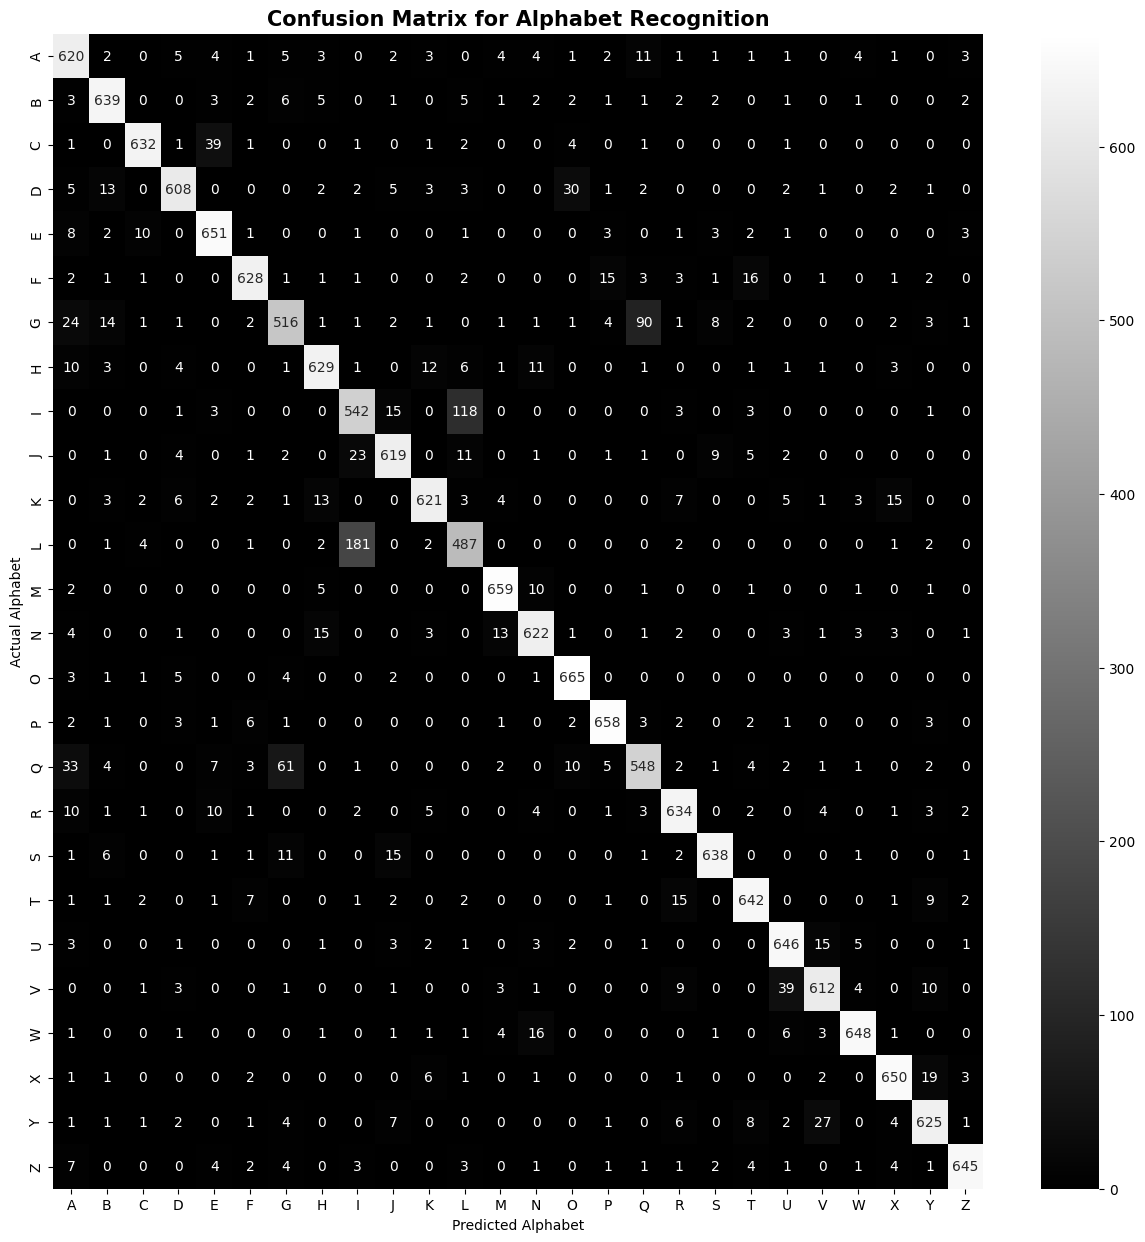

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convert one-hot encoded labels back to normal labels
y_test_letter_eval = y_true_classes

# Predict test images
y_predicts = y_pred_classes

# Confusion Matrix
con_mat = confusion_matrix(y_test_letter_eval, y_predicts)

# Alphabet labels
labels = alphabet_labels

plt.figure(figsize=(15,15))

sns.heatmap(
    con_mat, # Removed slicing [1:,1:] to include all classes (A-Z)
    annot=True,
    fmt='d',
    cmap='gray',
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Confusion Matrix for Alphabet Recognition",
    fontweight='bold',
    fontsize=15
)

plt.xlabel("Predicted Alphabet")
plt.ylabel("Actual Alphabet")

plt.show()

In [14]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


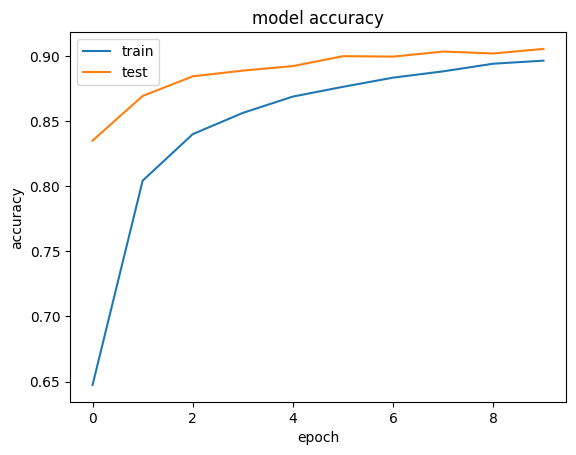

In [15]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

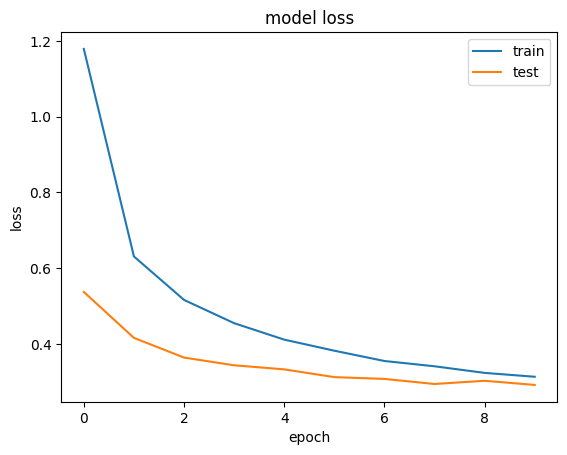

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


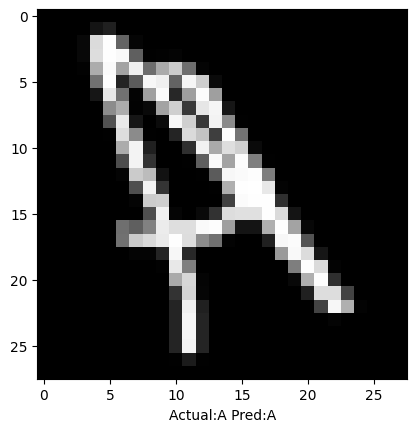

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Find alphabet A (A is 0-indexed as 0)
i = np.where(y_true_classes == 0)[0][0]

# Predict single image
y_predict_single = model.predict(X_test[[i]])
y_predict_single = np.argmax(y_predict_single, axis=1)

# Convert labels to alphabets
actual = alphabet_labels[y_true_classes[i]]
predicted = alphabet_labels[y_predict_single[0]]

# Display image
plt.imshow(X_test[i].reshape(28,28), cmap='gray')

plt.xlabel(
    "Actual:{} Pred:{}".format(
        actual,
        predicted
    )
)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


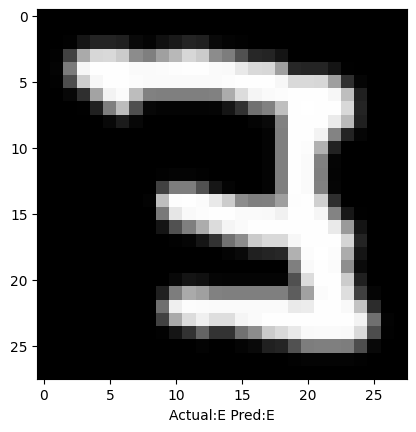

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Find alphabet E (E is 0-indexed as 0)
i = np.where(y_true_classes == 4)[0][0]

# Predict single image
y_predict_single = model.predict(X_test[[i]])
y_predict_single = np.argmax(y_predict_single, axis=1)

# Convert labels to alphabets
actual = alphabet_labels[y_true_classes[i]]
predicted = alphabet_labels[y_predict_single[0]]

# Display image
plt.imshow(X_test[i].reshape(28,28), cmap='gray')

plt.xlabel(
    "Actual:{} Pred:{}".format(
        actual,
        predicted
    )
)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


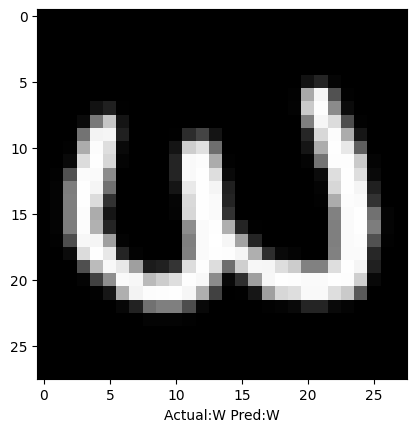

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Find alphabet W (W is 0-indexed as 0)
i = np.where(y_true_classes == 22)[0][0]

# Predict single image
y_predict_single = model.predict(X_test[[i]])
y_predict_single = np.argmax(y_predict_single, axis=1)

# Convert labels to alphabets
actual = alphabet_labels[y_true_classes[i]]
predicted = alphabet_labels[y_predict_single[0]]

# Display image
plt.imshow(X_test[i].reshape(28,28), cmap='gray')

plt.xlabel(
    "Actual:{} Pred:{}".format(
        actual,
        predicted
    )
)

plt.show()

| Alphabet | Index |
| -------- | ----- |
| A        | 0     |
| B        | 1     |
| C        | 2     |
| D        | 3     |
| E        | 4     |
| F        | 5     |
| G        | 6     |
| H        | 7     |
| I        | 8     |
| J        | 9     |
| K        | 10    |
| L        | 11    |
| M        | 12    |
| N        | 13    |
| O        | 14    |
| P        | 15    |
| Q        | 16    |
| R        | 17    |
| S        | 18    |
| T        | 19    |
| U        | 20    |
| V        | 21    |
| W        | 22    |
| X        | 23    |
| Y        | 24    |
| Z        | 25    |


Confusion Matrix:

The confusion matrix shows that most values are concentrated on the diagonal, indicating correct predictions. **Alphabet O showed a high correct prediction value (663)**, meaning the model learned that class well.

===================

Classification Report:

The classification report shows that the model achieved an **overall accuracy of 91%.** Alphabets M, O, W, X, and Z showed strong performance with high scores.

In [20]:
model.save("alphabet_model.h5")

# New section

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
%%writefile app.py
import streamlit as st
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np

model = load_model("alphabet_model.h5")

labels=[chr(i) for i in range(65,91)]

st.title("Handwritten Alphabet Recognition using ANN")

uploaded_file=st.file_uploader(
    "Upload image",
    type=["png","jpg","jpeg"]
)

if uploaded_file is not None:

    img=Image.open(uploaded_file).convert('L')

    img=img.resize((28,28))

    img=np.array(img)

    img=img/255.0

    img=img.reshape(1,784)

    prediction=model.predict(img)

    pred=np.argmax(prediction)

    st.success(
        f"Predicted Alphabet: {labels[pred]}"
    )

Writing app.py


In [23]:
%%writefile requirements.txt
streamlit
tensorflow
numpy
pillow

Writing requirements.txt
